### Initializing

In [1]:
# importing necessary libaries

from fredapi import Fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller



fred = Fred(api_key="39b0a44095f9731b6ab14b05ca4fc2d1")

In [2]:
# gathering data

vmt = fred.get_series("TRFVOLUSM227SFWA")
gas_price = fred.get_series("GASREGW")
auto_sales = fred.get_series("TOTALSA")
unrate = fred.get_series("UNRATE")
cpi = fred.get_series("CPIAUCSL")
indpro = fred.get_series("INDPRO")
fedfunds = fred.get_series("FEDFUNDS")

In [3]:
# creating dataframe of variables 
df = pd.concat(
    [vmt, gas_price, auto_sales, unrate, cpi, indpro, fedfunds],
    axis=1
)

# naming columns
df.columns = ["VMT", "GASPRICE", "AUTOSALES", "UNRATE", "CPI", "INDPRO", "FEDFUNDS"]

# setting index to datetime
df.index = pd.to_datetime(df.index)

# filtering from 2000+
df = df.loc["2000":]

# fixing weekly data
df = df.resample("M").mean()
df.index = df.index.to_period("M").to_timestamp()

# dropping nan
df.loc["2025-10-01", ["UNRATE", "CPI"]] = df.loc["2025-09-01", ["UNRATE", "CPI"]]
df = df.dropna()

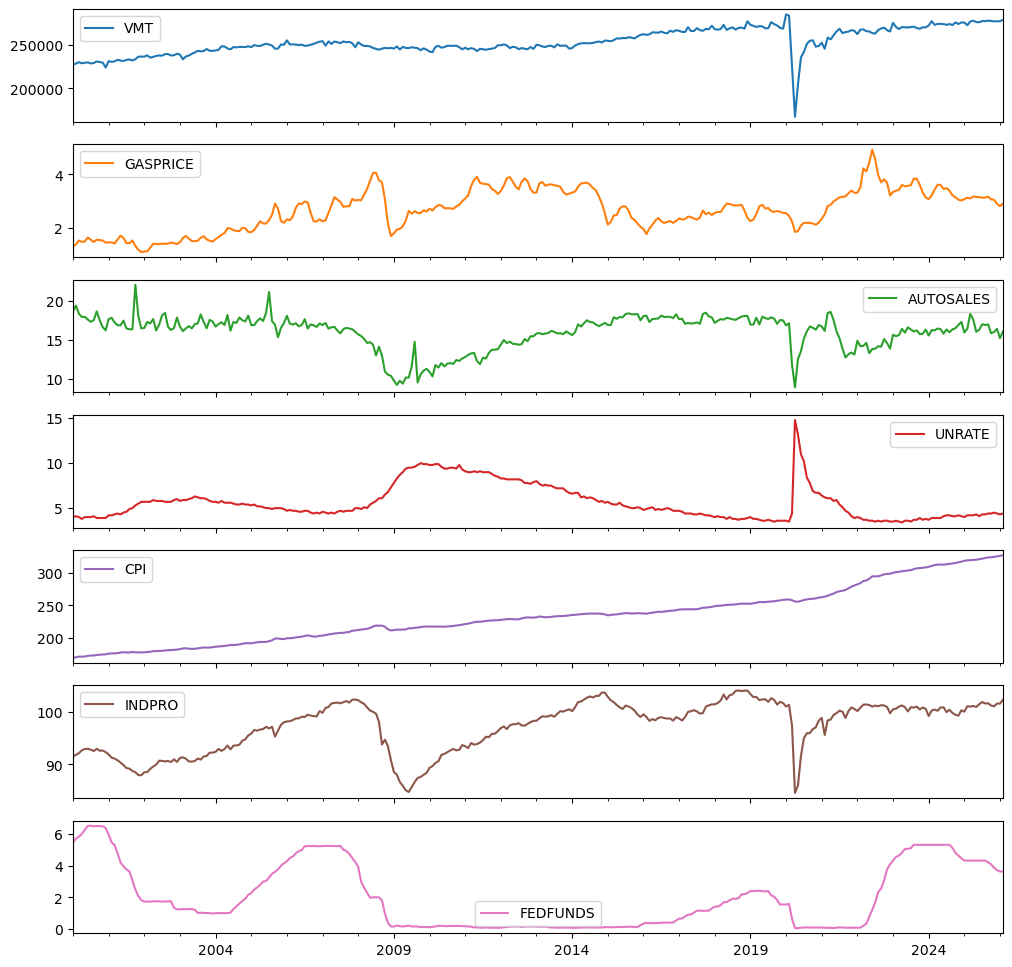

In [4]:
# plotting all of the data
df.plot(subplots=True, figsize=(12, 12))
plt.show()

In [5]:
# summary stats
summary_stats = df.describe().T

summary_stats["skewness"] = df.skew()
summary_stats["kurtosis"] = df.kurtosis()

summary_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
VMT,314.0,254012.254777,14552.170562,167174.0000,245953.250000,250683.50000,267017.250000,285452.0000,-0.652894,3.161912
GASPRICE,314.0,2.656713,0.773258,1.0860,2.149125,2.71000,3.260312,4.9290,-0.022011,-0.722038
AUTOSALES,314.0,16.001061,2.162643,8.9190,15.189500,16.58500,17.484250,22.0550,-1.178619,1.258409
UNRATE,314.0,5.632166,1.939224,3.4000,4.200000,5.00000,6.200000,14.8000,1.316131,1.660781
CPI,314.0,234.062736,41.964892,169.3000,201.925000,231.73800,255.802000,327.4600,0.541866,-0.478378
INDPRO,314.0,97.263012,4.728157,84.5619,92.980950,98.94125,101.019875,104.1004,-0.728931,-0.569078
FEDFUNDS,314.0,2.018185,2.029514,0.0500,0.150000,1.26000,3.962500,6.5400,0.703952,-0.953430


---

### Data Transformation

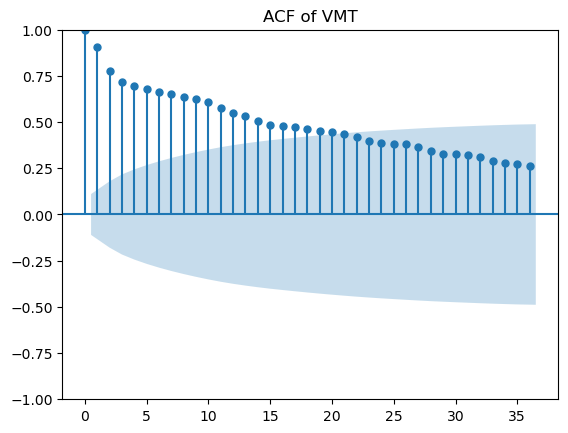

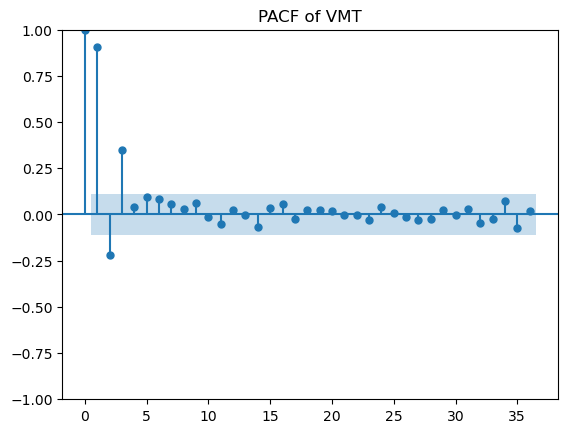

In [6]:
# first we are going to look at our dependent variable and check if there is stationarity
plot_acf(df["VMT"], lags=36)
plt.title("ACF of VMT")
plt.show()

plot_pacf(df["VMT"], lags=36)
plt.title("PACF of VMT")
plt.show()

In [7]:
# now we are going to run dicky fuller test to check stationarity in all series
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"{name}")
    print(f"ADF statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print()

for col in df.columns:
    adf_test(df[col], col)

VMT
ADF statistic: -2.0452
p-value: 0.2671

GASPRICE
ADF statistic: -2.1022
p-value: 0.2436

AUTOSALES
ADF statistic: -2.9818
p-value: 0.0366

UNRATE
ADF statistic: -2.9911
p-value: 0.0357

CPI
ADF statistic: 1.2797
p-value: 0.9965

INDPRO
ADF statistic: -2.0837
p-value: 0.2511

FEDFUNDS
ADF statistic: -3.9935
p-value: 0.0014



In [8]:
# transforming variables 
df_transformed = pd.DataFrame(index=df.index)

# dependent variables: transforming VMT into monthly growth
df_transformed["dlog_VMT"] = np.log(df["VMT"]).diff()

# non-stationary positive level varaibles: log difference
df_transformed["dlog_GASPRICE"] = np.log(df["GASPRICE"]).diff()
df_transformed["dlog_CPI"] = np.log(df["CPI"]).diff()
df_transformed["dlog_INDPRO"] = np.log(df["INDPRO"]).diff()

# stationary variables: keep in levels
df_transformed["AUTOSALES"] = df["AUTOSALES"]
df_transformed["UNRATE"] = df["UNRATE"]
df_transformed["FEDFUNDS"] = df["FEDFUNDS"]

df_transformed = df_transformed.dropna()

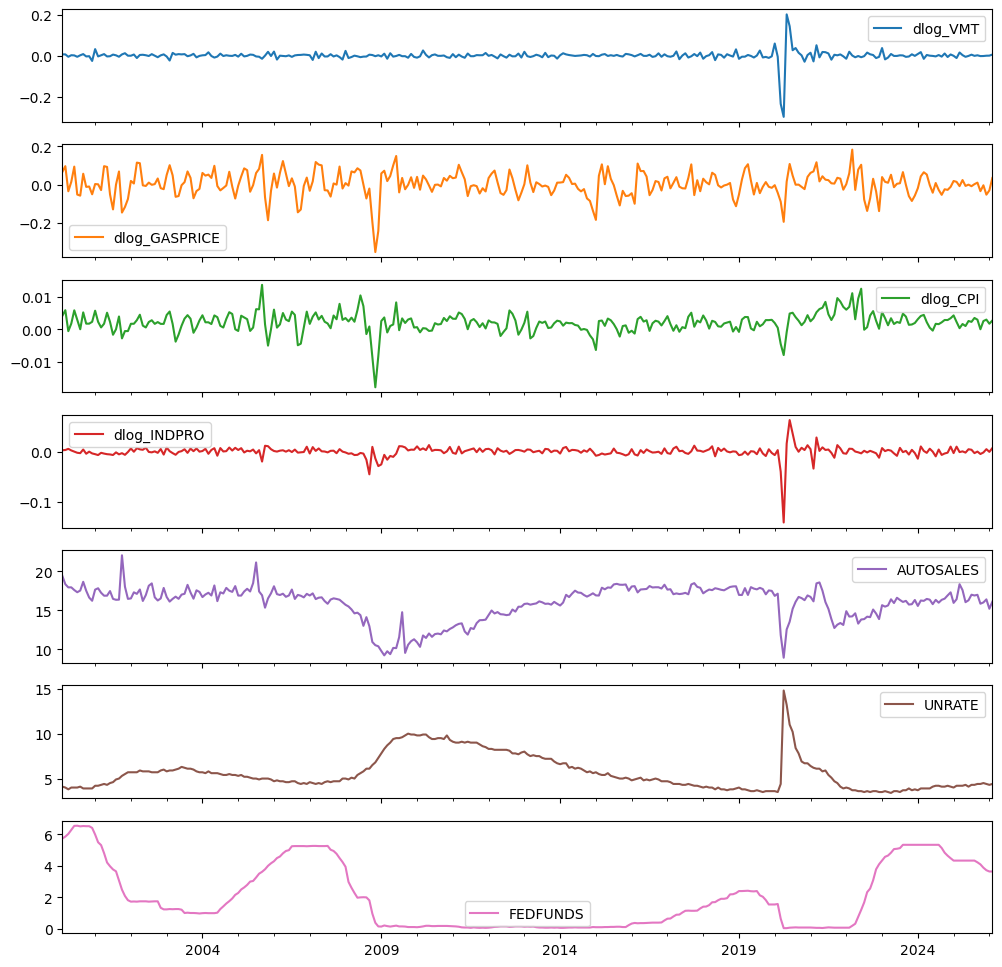

In [9]:
df_transformed.plot(subplots=True, figsize=(12, 12))
plt.show()

---

### Methodology

In [10]:
# Naive Mean Model
def naive_mean_model(y, train, h=1):
    # initiating forecasting holdout
    start_origin = train.index.max() 

    # adding a stopper to not forecast data not recorded 
    last_origin = y.index.max() - pd.DateOffset(months=h)

    # saving avaliable forecasting dates/months to a list
    origins = y.loc[start_origin:last_origin].index

    # creating a list to store forecasting data (i.e. the forecast, actual value, error, etc.)
    rows = []

    # now we are looping through each date in the forecast holdout window
    for t in origins:
        # this selects all the dates avaliable up to time t
        hist = y.loc[:t]

        # this specifies the date we are forecasting (in this case, it is the next month's date)      
        target = t + pd.DateOffset(months=h)   

        # this just specifies the actual value instead of the forecast
        actual = y.loc[target]

        # this computes the mean of the dates before the forecast which will ultimately be our forecast
        forecast = hist.mean()

        # now we just compile the data into a dictionary and append it to our empty list and this will continue throughout the for loop
        rows.append({
            "origin": t,
            "target": target,
            "actual": actual,
            "forecast": forecast,
            "error": forecast - actual,
            "sq_error": (forecast - actual) ** 2,
            "abs_error": abs(forecast - actual),
            "model": "Naive Mean",
            "h": h
        })

    return pd.DataFrame(rows)

In [11]:
# Random Walk Model
def random_walk_model(h, y, train):
    # initiating forecasting holdout
    start_origin = train.index.max()

    # adding a stopper to not forecast data not recorded
    last_origin = y.index.max() - pd.DateOffset(months=h)

    # saving avaliable forecasting dates/months to a list
    origins = y.loc[start_origin:last_origin].index

    # creating a list to store forecasting data
    rows = []

    # now we are looping through each date in the forecast holdout window
    for t in origins:
        # this specifies the date we are forecasting
        target = t + pd.DateOffset(months=h)

        # this just specifies the actual value instead of the forecast
        actual = y.loc[target]

        # random walk model: forecast equals the last observed value at time t
        forecast = y.loc[t]

        # this calculates the forecast error
        error = forecast - actual

        # now we just compile the data into a dictionary and append it to our empty list and this will continue throughout the for loop
        rows.append({
            "origin": t,
            "target": target,
            "actual": actual,
            "forecast": forecast,
            "error": error,
            "sq_error": error ** 2,
            "abs_error": abs(error),
            "model": "Random Walk",
            "h": h
        })

    results = pd.DataFrame(rows)
    return results

In [12]:
# Random Walk w/ Drift Model
def random_walk_drift_model(h, y, train):
    # initiating forecasting holdout
    start_origin = train.index.max()

    # adding a stopper to not forecast data not recorded
    last_origin = y.index.max() - pd.DateOffset(months=h)

    # saving avaliable forecasting dates/months to a list
    origins = y.loc[start_origin:last_origin].index

    # creating a list to store forecasting data
    rows = []

    # now we are looping through each date in the forecast holdout window
    for t in origins:
        # this specifies the date we are forecasting
        target = t + pd.DateOffset(months=h)

        # this just specifies the actual value instead of the forecast
        actual = y.loc[target]

        # have to estimate drift from the training sample (average monthy change) so you have to take the first difference
        mu = y.loc[:t].diff().mean()

        # random walk with drift model: forecast equals the last observed value at time t plus h times the drift
        forecast = y.loc[t] + h * mu

        # this calculates the forecast error
        error = forecast - actual

        # now we just compile the data into a dictionary and append it to our empty list and this will continue throughout the for loop
        rows.append({
            "origin": t,
            "target": target,
            "actual": actual,
            "mu": mu,
            "forecast": forecast,
            "error": error,
            "sq_error": error ** 2,
            "abs_error": abs(error),
            "model": "Random Walk with Drift",
            "h": h
        })

    results = pd.DataFrame(rows)
    return results

In [13]:
# defining msfe and mae function
def forecast_accuracy(results):
    return pd.Series({
        "MSFE": results["sq_error"].mean(),
        "MAE": results["abs_error"].mean()
    })

In [14]:
# PCA code
X_macro = df_transformed[
    [
        "dlog_GASPRICE",
        "AUTOSALES",
        "UNRATE",
        "dlog_CPI",
        "dlog_INDPRO",
        "FEDFUNDS"
    ]
].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_macro)

pca = PCA(n_components=3)

factors = pca.fit_transform(X_scaled)
factor_df = pd.DataFrame(
    factors,
    index=X_macro.index,
    columns=["f1", "f2", "f3"]
)

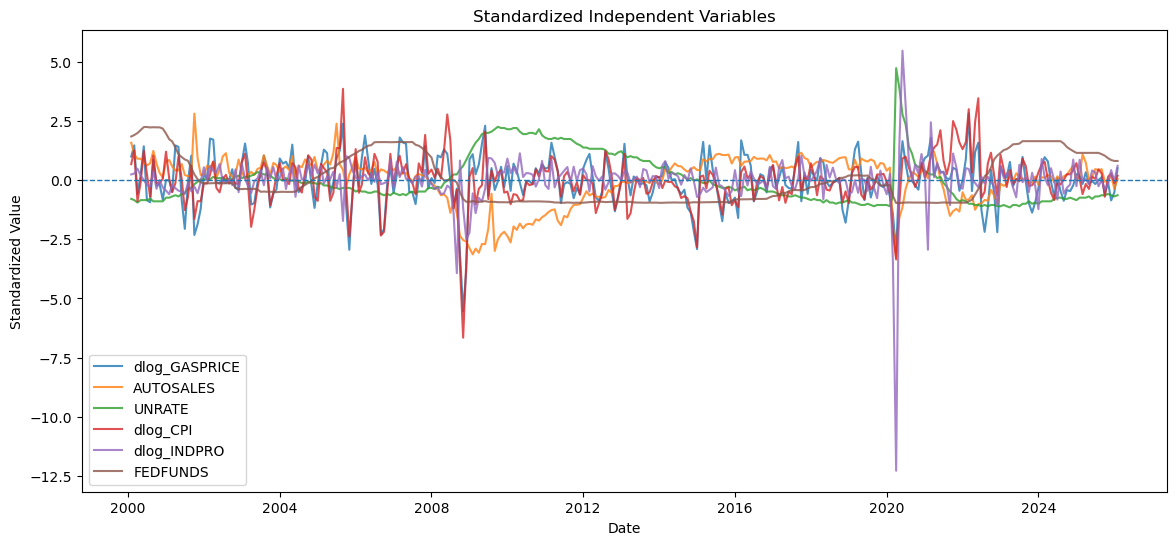

In [15]:
# standardize independent variables for plotting
X_macro_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_macro),
    index=X_macro.index,
    columns=X_macro.columns
)

plt.figure(figsize=(14, 6))

for col in X_macro_scaled.columns:
    plt.plot(X_macro_scaled.index, X_macro_scaled[col], label=col, alpha=0.8)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Standardized Independent Variables")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend(loc="best")
plt.show()

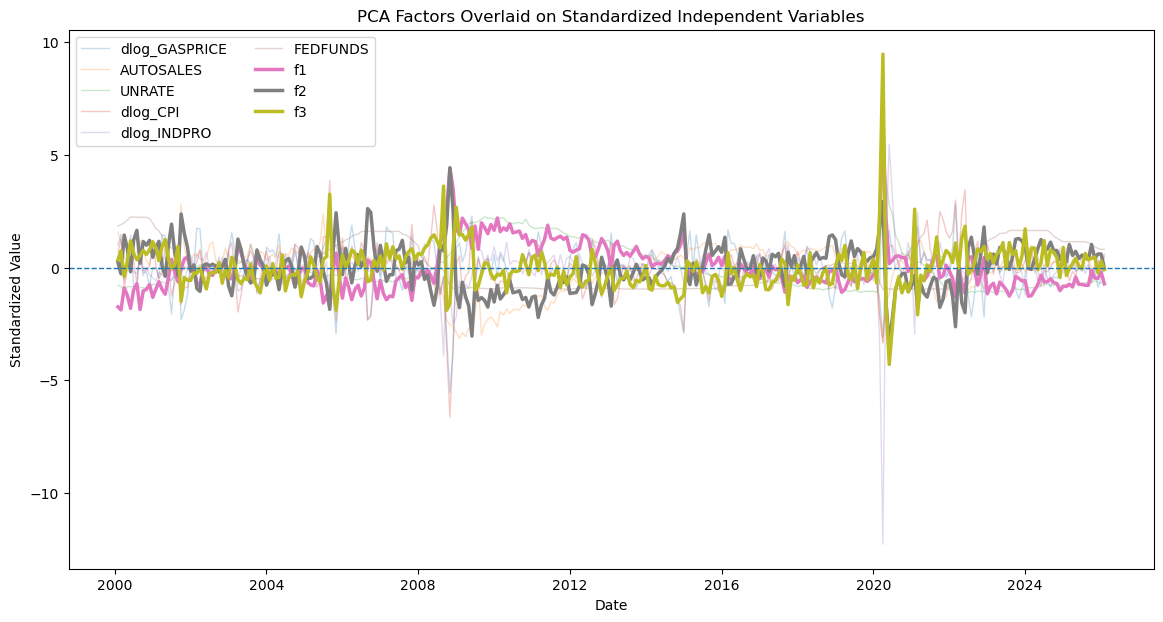

In [16]:
# standardize factors for plotting
factor_scaled = pd.DataFrame(
    StandardScaler().fit_transform(factor_df),
    index=factor_df.index,
    columns=factor_df.columns
)

# align dates
plot_data = pd.concat([X_macro_scaled, factor_scaled], axis=1).dropna()

plt.figure(figsize=(14, 7))

# plot independent variables
for col in X_macro_scaled.columns:
    plt.plot(plot_data.index, plot_data[col], alpha=0.25, linewidth=1, label=col)

# plot factors
for col in factor_scaled.columns:
    plt.plot(plot_data.index, plot_data[col], linewidth=2.5, label=col)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("PCA Factors Overlaid on Standardized Independent Variables")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend(loc="best", ncol=2)
plt.show()

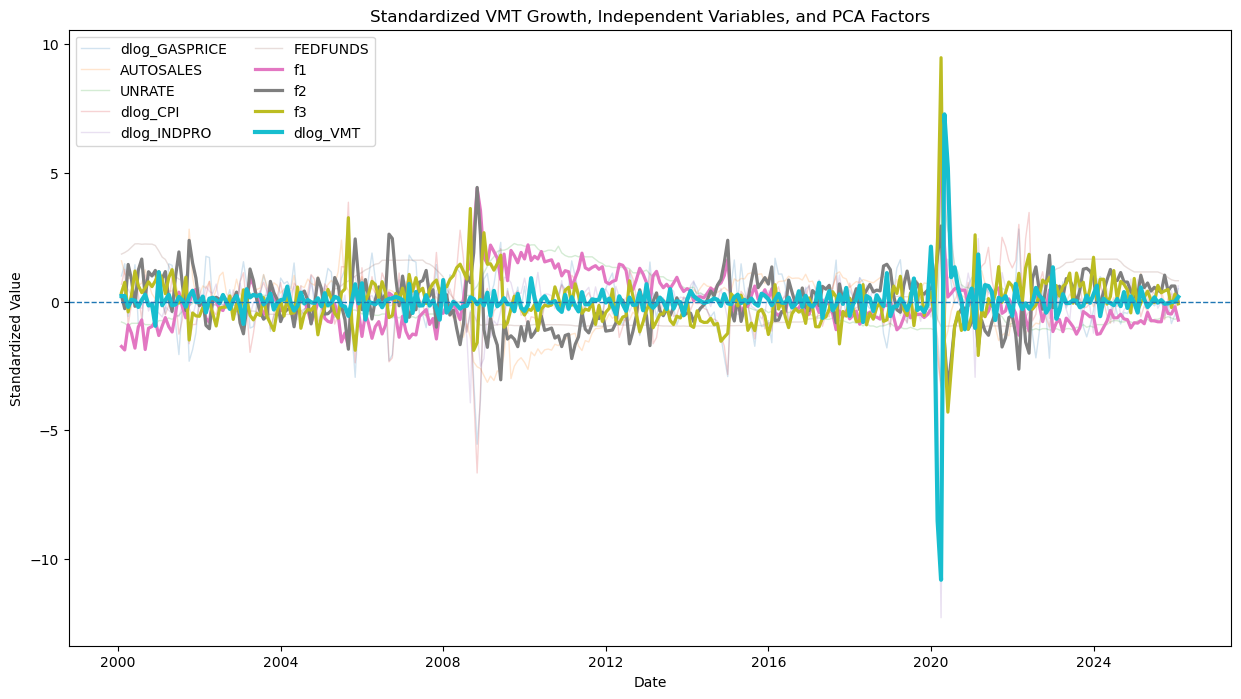

In [17]:
# standardize dependent variable for plotting
y_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_transformed[["dlog_VMT"]].dropna()),
    index=df_transformed[["dlog_VMT"]].dropna().index,
    columns=["dlog_VMT"]
)

# align all data
everything_plot = pd.concat(
    [y_scaled, X_macro_scaled, factor_scaled],
    axis=1
).dropna()

plt.figure(figsize=(15, 8))

# plot independent variables lightly
for col in X_macro_scaled.columns:
    plt.plot(everything_plot.index, everything_plot[col], alpha=0.2, linewidth=1, label=col)

# plot factors more strongly
for col in factor_scaled.columns:
    plt.plot(everything_plot.index, everything_plot[col], linewidth=2.3, label=col)

# plot dependent variable strongest
plt.plot(
    everything_plot.index,
    everything_plot["dlog_VMT"],
    linewidth=3,
    label="dlog_VMT"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Standardized VMT Growth, Independent Variables, and PCA Factors")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend(loc="best", ncol=2)
plt.show()

In [18]:
explained_variance = pd.DataFrame({
    "factor": ["f1", "f2", "f3"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": pca.explained_variance_ratio_.cumsum()
})

explained_variance

,factor,explained_variance_ratio,cumulative_variance
0,f1,0.369292,0.369292
1,f2,0.297056,0.666348
2,f3,0.154548,0.820896


In [19]:
# combining dependent variable with PCA factors
pca_model_df = pd.concat(
    [df_transformed["dlog_VMT"], factor_df],
    axis=1
).dropna()

# creating lagged dependent variable
pca_model_df["dlog_VMT_lag1"] = pca_model_df["dlog_VMT"].shift(1)

# creating lagged PCA factors
pca_model_df["f1_lag1"] = pca_model_df["f1"].shift(1)
pca_model_df["f2_lag1"] = pca_model_df["f2"].shift(1)
pca_model_df["f3_lag1"] = pca_model_df["f3"].shift(1)

# creating monthly dummies
month_dummies = pd.get_dummies(
    pca_model_df.index.month,
    prefix="month",
    drop_first=True
).astype(int)

month_dummies.index = pca_model_df.index

# adding monthly dummies to the modeling dataframe
pca_model_df = pd.concat(
    [pca_model_df, month_dummies],
    axis=1
).dropna()

pca_model_df.head()

,dlog_VMT,f1,f2,f3,dlog_VMT_lag1,f1_lag1,f2_lag1,f3_lag1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
2000-03-01,0.006580,-2.800192,-0.371260,0.720629,0.006544,-2.596651,0.309940,0.332896,0,1,0,0,0,0,0,0,0,0,0
2000-04-01,-0.005090,-1.343232,1.923363,-0.387590,0.006580,-2.800192,-0.371260,0.720629,0,0,1,0,0,0,0,0,0,0,0
2000-05-01,0.002542,-1.832743,1.136818,0.253431,-0.005090,-1.343232,1.923363,-0.387590,0,0,0,1,0,0,0,0,0,0,0
2000-06-01,0.001623,-2.694003,-0.248645,1.137305,0.002542,-1.832743,1.136818,0.253431,0,0,0,0,1,0,0,0,0,0,0
2000-07-01,-0.005161,-1.471858,1.627119,0.594822,0.001623,-2.694003,-0.248645,1.137305,0,0,0,0,0,1,0,0,0,0,0


In [20]:
# dependent variable
y_pca = pca_model_df["dlog_VMT"]

# independent variables
X_pca = pca_model_df[
    [
        "dlog_VMT_lag1",
        "f1_lag1",
        "f2_lag1",
        "f3_lag1"
    ] + list(month_dummies.columns)
]

# adding constant
X_pca = sm.add_constant(X_pca)

pca_model = sm.OLS(y_pca, X_pca).fit()
print(pca_model.summary())

                            OLS Regression Results                            
Dep. Variable:               dlog_VMT   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     3.728
Date:                Sun, 03 May 2026   Prob (F-statistic):           5.00e-06
Time:                        15:31:25   Log-Likelihood:                 704.95
No. Observations:                 312   AIC:                            -1378.
Df Residuals:                     296   BIC:                            -1318.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0068      0.005      1.311

In [21]:
# pca forecasting model
def pca_factor_forecast_model(h, data, train):
    # initiating forecasting holdout
    start_origin = train.index.max()

    # adding a stopper to not forecast data not recorded
    last_origin = data.index.max() - pd.DateOffset(months=h)

    # saving avaliable forecasting dates/months to a list
    origins = data.loc[start_origin:last_origin].index

    # creating a list to store forecasting data
    rows = []

    # defining the variables used in the model
    x_vars = [
        "dlog_VMT_lag1",
        "f1_lag1",
        "f2_lag1",
        "f3_lag1"
    ] + list(month_dummies.columns)

    # now we are looping through each date in the forecast holdout window
    for t in origins:
        # this specifies the date we are forecasting
        target = t + pd.DateOffset(months=h)

        # this selects all the dates avaliable up to time t
        hist = data.loc[:t]

        # this specifies the actual value instead of the forecast
        actual = data.loc[target, "dlog_VMT"]

        # this separates the dependent and independent variables for the historical training sample
        y_train = hist["dlog_VMT"]
        X_train = hist[x_vars]

        # adding a constant to the training regressors
        X_train = sm.add_constant(X_train, has_constant="add")

        # estimating the factor-augmented regression model
        model = sm.OLS(y_train, X_train).fit()

        # this gets the predictor values available at time t for forecasting the target
        X_forecast = data.loc[[t], x_vars]

        # adding a constant to the forecast regressors
        X_forecast = sm.add_constant(X_forecast, has_constant="add")

        # this computes the forecast
        forecast = model.predict(X_forecast).iloc[0]

        # this calculates the forecast error
        error = forecast - actual

        # now we just compile the data into a dictionary and append it to our empty list and this will continue throughout the for loop
        rows.append({
            "origin": t,
            "target": target,
            "actual": actual,
            "forecast": forecast,
            "error": error,
            "sq_error": error ** 2,
            "abs_error": abs(error),
            "model": "PCA Factor Model",
            "h": h
        })

    results = pd.DataFrame(rows)
    return results

In [22]:
# standard regression model
# starting with transformed data
reg_model_df = df_transformed.copy()

# creating lagged dependent variable
reg_model_df["dlog_VMT_lag1"] = reg_model_df["dlog_VMT"].shift(1)

# creating lagged macro variables
macro_vars = [
    "dlog_GASPRICE",
    "AUTOSALES",
    "UNRATE",
    "dlog_CPI",
    "dlog_INDPRO",
    "FEDFUNDS"
]

for col in macro_vars:
    reg_model_df[f"{col}_lag1"] = reg_model_df[col].shift(1)

# creating monthly dummies
month_dummies = pd.get_dummies(
    reg_model_df.index.month,
    prefix="month",
    drop_first=True
).astype(int)

month_dummies.index = reg_model_df.index

# adding monthly dummies to the modeling dataframe
reg_model_df = pd.concat(
    [reg_model_df, month_dummies],
    axis=1
).dropna()

In [23]:
# dependent variable
y_reg = reg_model_df["dlog_VMT"]

# independent variables
x_vars_reg = (
    ["dlog_VMT_lag1"]
    + [f"{col}_lag1" for col in macro_vars]
    + list(month_dummies.columns)
)

X_reg = reg_model_df[x_vars_reg]

# making sure everything is numeric
X_reg = X_reg.astype(float)
y_reg = y_reg.astype(float)

# adding constant
X_reg = sm.add_constant(X_reg, has_constant="add")

macro_reg_model = sm.OLS(y_reg, X_reg).fit()
print(macro_reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:               dlog_VMT   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     6.261
Date:                Sun, 03 May 2026   Prob (F-statistic):           5.43e-13
Time:                        15:31:25   Log-Likelihood:                 728.73
No. Observations:                 312   AIC:                            -1419.
Df Residuals:                     293   BIC:                            -1348.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0999      0

In [24]:
def macro_regression_forecast_model(h, data, train):
    # initiating forecasting holdout
    start_origin = train.index.max()

    # adding a stopper to not forecast data not recorded
    last_origin = data.index.max() - pd.DateOffset(months=h)

    # saving avaliable forecasting dates/months to a list
    origins = data.loc[start_origin:last_origin].index

    # creating a list to store forecasting data
    rows = []

    # defining the variables used in the model
    x_vars = (
        ["dlog_VMT_lag1"]
        + [f"{col}_lag1" for col in macro_vars]
        + [col for col in data.columns if col.startswith("month_")]
    )

    # now we are looping through each date in the forecast holdout window
    for t in origins:
        # this specifies the date we are forecasting
        target = t + pd.DateOffset(months=h)

        # this selects all the dates avaliable up to time t
        hist = data.loc[:t]

        # this specifies the actual value instead of the forecast
        actual = data.loc[target, "dlog_VMT"]

        # this separates the dependent and independent variables for the historical training sample
        y_train = hist["dlog_VMT"]
        X_train = hist[x_vars]

        # making sure all regressors are numeric
        X_train = X_train.astype(float)
        y_train = y_train.astype(float)

        # adding a constant to the training regressors
        X_train = sm.add_constant(X_train, has_constant="add")

        # estimating the full macro regression model
        model = sm.OLS(y_train, X_train).fit()

        # this gets the predictor values available at time t for forecasting the target
        X_forecast = data.loc[[t], x_vars]

        # making sure all regressors are numeric
        X_forecast = X_forecast.astype(float)

        # adding a constant to the forecast regressors
        X_forecast = sm.add_constant(X_forecast, has_constant="add")

        # this computes the forecast
        forecast = model.predict(X_forecast).iloc[0]

        # this calculates the forecast error
        error = forecast - actual

        # now we just compile the data into a dictionary and append it to our empty list and this will continue throughout the for loop
        rows.append({
            "origin": t,
            "target": target,
            "actual": actual,
            "forecast": forecast,
            "error": error,
            "sq_error": error ** 2,
            "abs_error": abs(error),
            "model": "Full Macro Regression",
            "h": h
        })

    results = pd.DataFrame(rows)
    return results

---

### Forecasting Results

In [25]:
# defining target variable
y = df_transformed["dlog_VMT"]

# defining train samples
train_y = y.loc[: "2018-12-01"]
train_pca = pca_model_df.loc[: "2018-12-01"]
train_reg = reg_model_df.loc[: "2018-12-01"]

y.tail()


2025-10-01   -0.001730
2025-11-01   -0.001336
2025-12-01    0.000130
2026-01-01    0.000479
2026-02-01    0.005615
Freq: MS, Name: dlog_VMT, dtype: float64

In [26]:
# h=1
naive_h1 = naive_mean_model(
    h=1,
    y=y,
    train=train_y
)

rw_h1 = random_walk_model(
    h=1,
    y=y,
    train=train_y
)

rwd_h1 = random_walk_drift_model(
    h=1,
    y=y,
    train=train_y
)

pca_h1 = pca_factor_forecast_model(
    h=1,
    data=pca_model_df,
    train=train_pca
)

macro_reg_h1 = macro_regression_forecast_model(
    h=1,
    data=reg_model_df,
    train=train_reg
)

In [27]:
# h = 12
naive_h12 = naive_mean_model(
    h=12,
    y=y,
    train=train_y
)

rw_h12 = random_walk_model(
    h=12,
    y=y,
    train=train_y
)

rwd_h12 = random_walk_drift_model(
    h=12,
    y=y,
    train=train_y
)

pca_h12 = pca_factor_forecast_model(
    h=12,
    data=pca_model_df,
    train=train_pca
)

macro_reg_h12 = macro_regression_forecast_model(
    h=12,
    data=reg_model_df,
    train=train_reg
)

In [28]:
accuracy_h1 = pd.concat([
    forecast_accuracy(naive_h1).rename("Naive Mean"),
    forecast_accuracy(rw_h1).rename("Random Walk"),
    forecast_accuracy(rwd_h1).rename("Random Walk with Drift"),
    forecast_accuracy(pca_h1).rename("PCA Factor Model"),
    forecast_accuracy(macro_reg_h1).rename("Full Macro Regression")
], axis=1).T

accuracy_h12 = pd.concat([
    forecast_accuracy(naive_h12).rename("Naive Mean"),
    forecast_accuracy(rw_h12).rename("Random Walk"),
    forecast_accuracy(rwd_h12).rename("Random Walk with Drift"),
    forecast_accuracy(pca_h12).rename("PCA Factor Model"),
    forecast_accuracy(macro_reg_h12).rename("Full Macro Regression")
], axis=1).T

In [29]:
print("Forecast Accuracy: h = 1")
display(accuracy_h1)

print("Forecast Accuracy: h = 12")
display(accuracy_h12)

Forecast Accuracy: h = 1


,MSFE,MAE
Naive Mean,0.002574,0.019261
Random Walk,0.004194,0.025421
Random Walk with Drift,0.004211,0.025470
PCA Factor Model,0.003857,0.024069
Full Macro Regression,0.004008,0.027715


Forecast Accuracy: h = 12


,MSFE,MAE
Naive Mean,0.002924,0.020793
Random Walk,0.006052,0.037788
Random Walk with Drift,0.006360,0.038757
PCA Factor Model,0.003637,0.026519
Full Macro Regression,0.004100,0.033341


In [30]:
# robustness check
robust_cutoff = "2015-12-01"

# defining target variable
y = df_transformed["dlog_VMT"]

# defining train samples using alternative cutoff
train_y_robust = y.loc[: robust_cutoff]
train_pca_robust = pca_model_df.loc[: robust_cutoff]
train_reg_robust = reg_model_df.loc[: robust_cutoff]



In [32]:
naive_h1_robust = naive_mean_model(
    h=1,
    y=y,
    train=train_y_robust
)

rw_h1_robust = random_walk_model(
    h=1,
    y=y,
    train=train_y_robust
)

rwd_h1_robust = random_walk_drift_model(
    h=1,
    y=y,
    train=train_y_robust
)

pca_h1_robust = pca_factor_forecast_model(
    h=1,
    data=pca_model_df,
    train=train_pca_robust
)

macro_reg_h1_robust = macro_regression_forecast_model(
    h=1,
    data=reg_model_df,
    train=train_reg_robust
)

In [34]:
naive_h12_robust = naive_mean_model(
    h=12,
    y=y,
    train=train_y_robust
)

rw_h12_robust = random_walk_model(
    h=12,
    y=y,
    train=train_y_robust
)

rwd_h12_robust = random_walk_drift_model(
    h=12,
    y=y,
    train=train_y_robust
)

pca_h12_robust = pca_factor_forecast_model(
    h=12,
    data=pca_model_df,
    train=train_pca_robust
)

macro_reg_h12_robust = macro_regression_forecast_model(
    h=12,
    data=reg_model_df,
    train=train_reg_robust
)

In [35]:
accuracy_h1_robust = pd.concat([
    forecast_accuracy(naive_h1_robust).rename("Naive Mean"),
    forecast_accuracy(rw_h1_robust).rename("Random Walk"),
    forecast_accuracy(rwd_h1_robust).rename("Random Walk with Drift"),
    forecast_accuracy(pca_h1_robust).rename("PCA Factor Model"),
    forecast_accuracy(macro_reg_h1_robust).rename("Full Macro Regression")
], axis=1).T

accuracy_h12_robust = pd.concat([
    forecast_accuracy(naive_h12_robust).rename("Naive Mean"),
    forecast_accuracy(rw_h12_robust).rename("Random Walk"),
    forecast_accuracy(rwd_h12_robust).rename("Random Walk with Drift"),
    forecast_accuracy(pca_h12_robust).rename("PCA Factor Model"),
    forecast_accuracy(macro_reg_h12_robust).rename("Full Macro Regression")
], axis=1).T


print("Robustness Check Forecast Accuracy: h = 1")
display(accuracy_h1_robust)

print("Robustness Check Forecast Accuracy: h = 12")
display(accuracy_h12_robust)

Robustness Check Forecast Accuracy: h = 1


,MSFE,MAE
Naive Mean,0.001845,0.015809
Random Walk,0.003036,0.021775
Random Walk with Drift,0.003049,0.021820
PCA Factor Model,0.002752,0.019276
Full Macro Regression,0.002858,0.021857


Robustness Check Forecast Accuracy: h = 12


,MSFE,MAE
Naive Mean,0.002018,0.016876
Random Walk,0.004123,0.027935
Random Walk with Drift,0.004332,0.028593
PCA Factor Model,0.002500,0.020788
Full Macro Regression,0.002812,0.025350


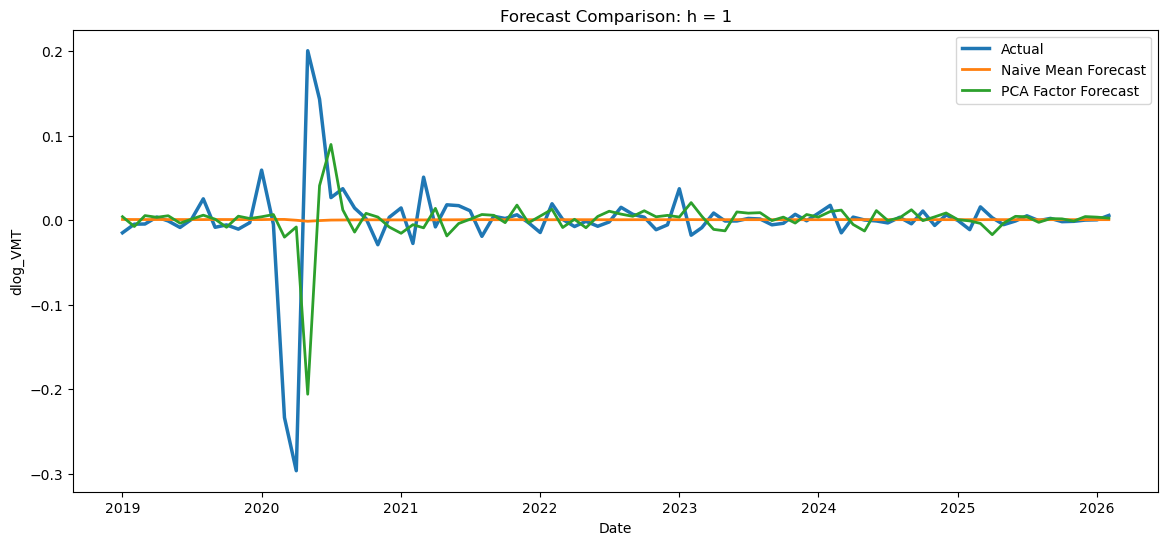

In [36]:
plot_h1 = pd.DataFrame({
    "actual": naive_h1["actual"].values,
    "naive_mean_forecast": naive_h1["forecast"].values,
    "pca_factor_forecast": pca_h1["forecast"].values
}, index=naive_h1["target"])

plot_h1 = plot_h1.sort_index()

plt.figure(figsize=(14, 6))
plt.plot(plot_h1.index, plot_h1["actual"], label="Actual", linewidth=2.5)
plt.plot(plot_h1.index, plot_h1["naive_mean_forecast"], label="Naive Mean Forecast", linewidth=2)
plt.plot(plot_h1.index, plot_h1["pca_factor_forecast"], label="PCA Factor Forecast", linewidth=2)

plt.title("Forecast Comparison: h = 1")
plt.xlabel("Date")
plt.ylabel("dlog_VMT")
plt.legend()
plt.show()

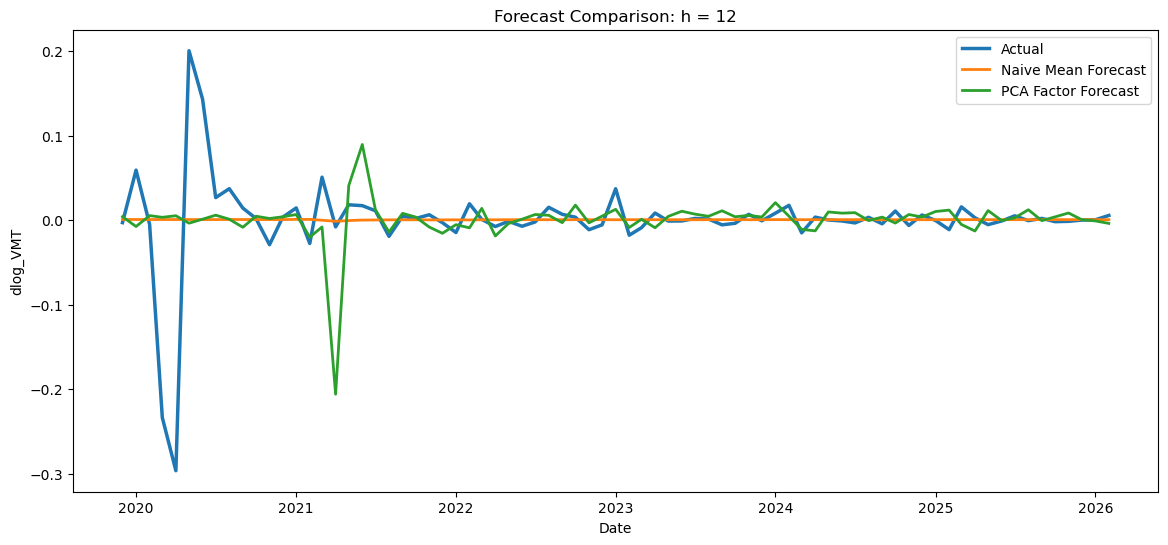

In [37]:
plot_h12 = pd.DataFrame({
    "actual": naive_h12["actual"].values,
    "naive_mean_forecast": naive_h12["forecast"].values,
    "pca_factor_forecast": pca_h12["forecast"].values
}, index=naive_h12["target"])

plot_h12 = plot_h12.sort_index()

plt.figure(figsize=(14, 6))
plt.plot(plot_h12.index, plot_h12["actual"], label="Actual", linewidth=2.5)
plt.plot(plot_h12.index, plot_h12["naive_mean_forecast"], label="Naive Mean Forecast", linewidth=2)
plt.plot(plot_h12.index, plot_h12["pca_factor_forecast"], label="PCA Factor Forecast", linewidth=2)

plt.title("Forecast Comparison: h = 12")
plt.xlabel("Date")
plt.ylabel("dlog_VMT")
plt.legend()
plt.show()